# Apply detector to entire DataFrame at once 

In [15]:
import pandas as pd
from tsod import (
    CombinedDetector,
    RangeDetector,
    ConstantGradientDetector,
    GradientDetector
)
import matplotlib.pyplot as plt

### Prepare example data

In [16]:
df = pd.read_csv("../tests/data/Ballen_20150218-20201222.csv", index_col=0, parse_dates=True)

In [17]:
# DATA MANIPULATION: Emulate multiple sensors from a single time series
# This function is used to demonstrate tsod's DataFrame capabilities by creating
# synthetic "multi-sensor" data from one long time series (splitting by year).
# NOTE: This reshaping introduces NaN but TSOD handles NaN values natively by ignoring them.
def emulate_multiple_sensors_from_timeseries(df):
    df_work = df.copy()
    df_work['year'] = df_work.index.year

    # Normalize all dates to 2016 for alignment (handle leap year Feb 29)
    df_work['date'] = df_work.index.map(
        lambda x: x.replace(year=2016) if (x.month != 2 or x.day != 29) or x.year == 2016
        else x.replace(year=2016, day=28)  # Feb 29 in non-leap years -> Feb 28
    )

    # Pivot: each year becomes a column (representing a different "sensor")
    df_sensors = df_work.pivot_table(
        index='date',
        columns='year',
        values='water_level',
        aggfunc='first'  # In case of duplicate timestamps
    )

    # Rename columns to obs_1, obs_2, etc. for clarity
    df_sensors.columns = [f'obs_{i+1}' for i, year in enumerate(df_sensors.columns)]
    return df_sensors


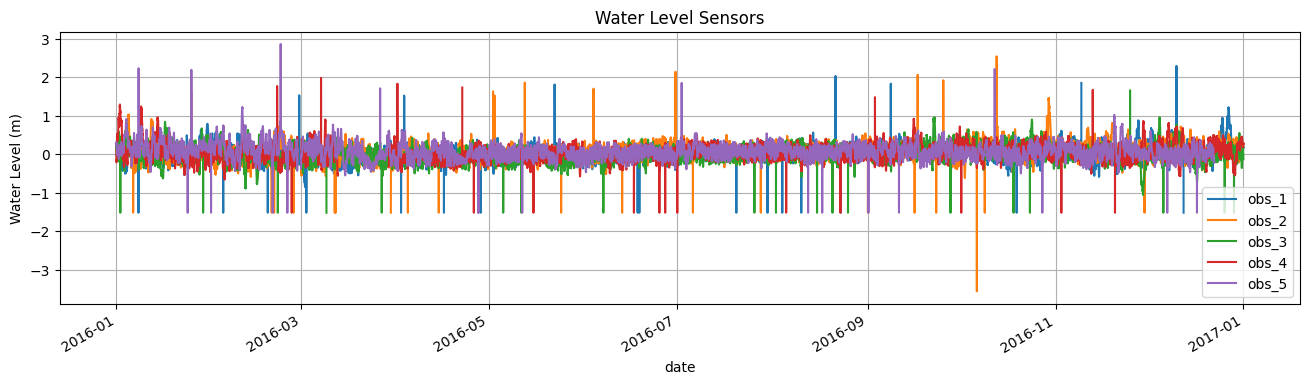

In [18]:
# Emulate multiple sensors from the time series data
df_sensors = emulate_multiple_sensors_from_timeseries(df.loc["2016":])
ax = df_sensors.plot(legend=True, figsize=(16, 4), grid=True, title='Water Level Sensors', ylabel='Water Level (m)')


### Detect anomalies using preset range and constant gradient rules

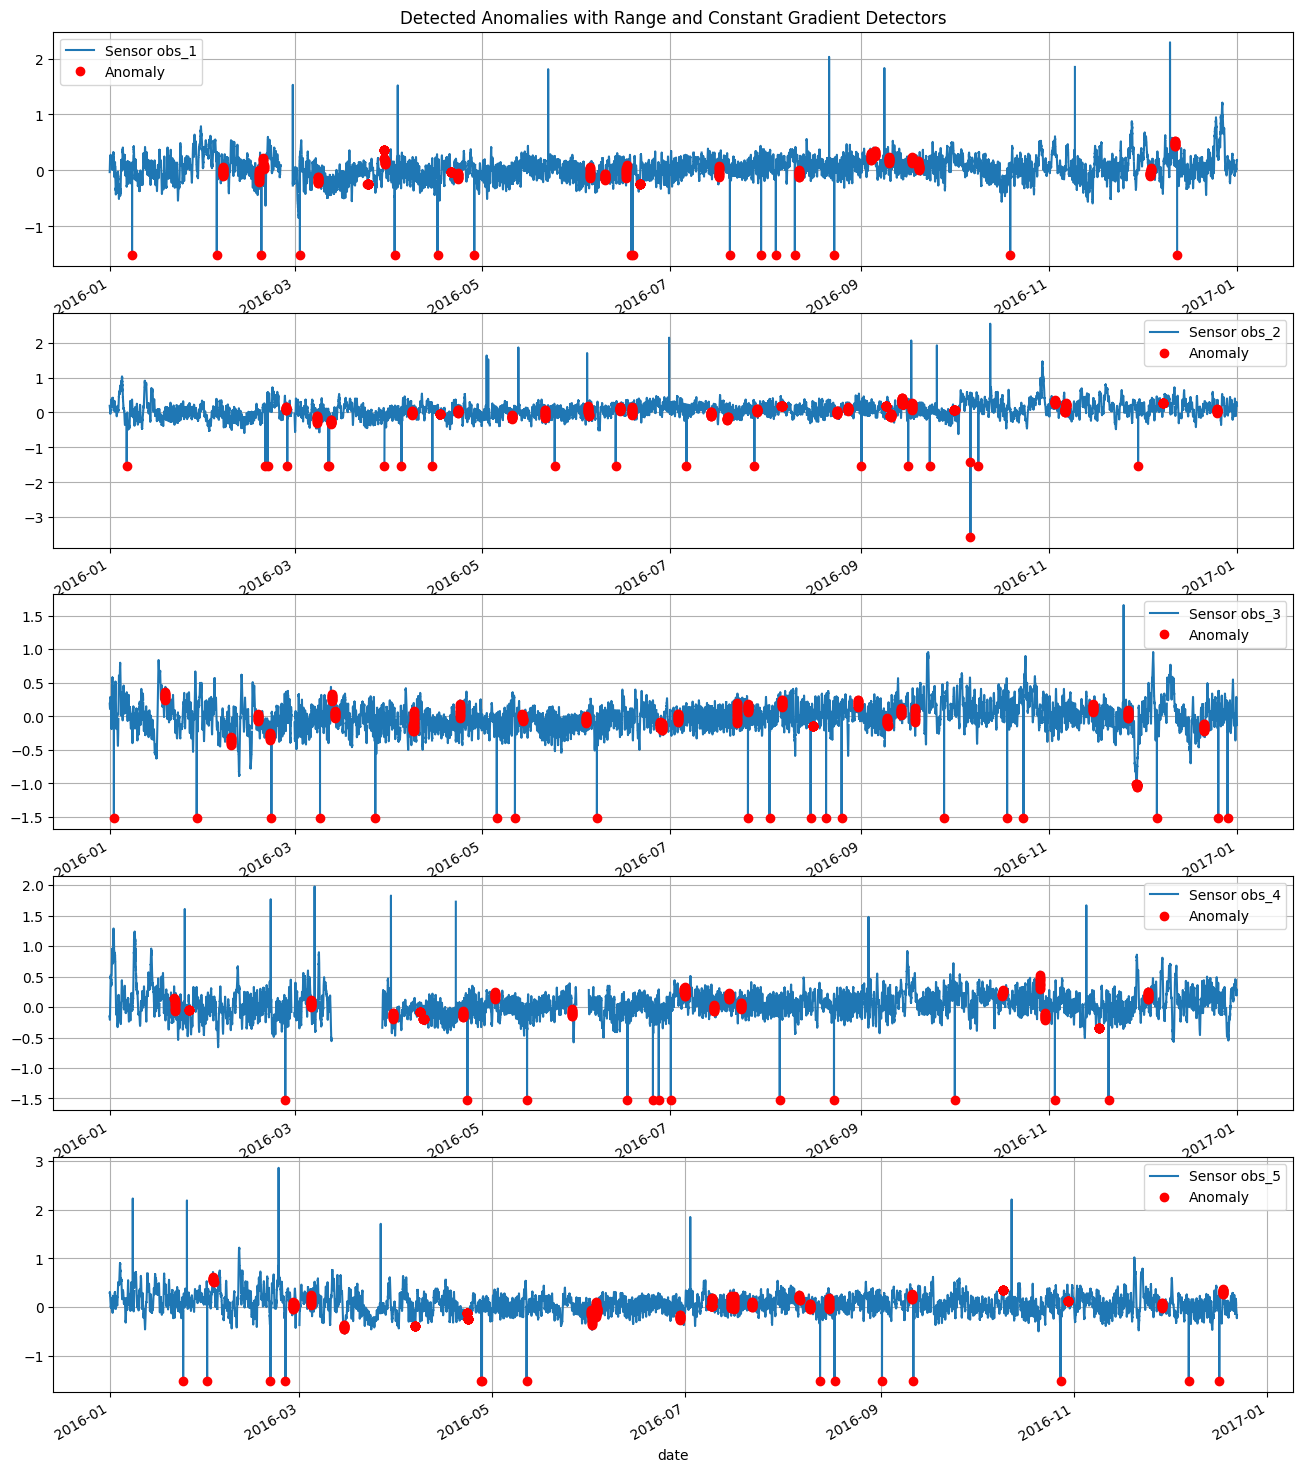

In [19]:
# Values within -1 to 10 m
range_detector = RangeDetector(min_value=-1.0, max_value=10.0) 
# Do not accept constant gradients over a window of 10 samples
constgrad_detector = ConstantGradientDetector(window_size=10) 

# Combine detectors
detector = CombinedDetector([
    range_detector, constgrad_detector
])

# Apply detector to entire DataFrame at once
anomalies = detector.detect(df_sensors)
# plot results
fig, ax = plt.subplots(5, 1, figsize=(16, 20))
ax[0].set_title('Detected Anomalies with Range and Constant Gradient Detectors')
for axis, col in zip(ax, df_sensors.columns):
    df_sensors[col].plot(ax=axis, grid=True, label=f'Sensor {col}')
    df_sensors[col][anomalies[col]].plot(style="ro", label="Anomaly", ax=axis, grid=True)
    axis.legend()

### Add gradient detector that has been fitted on a known good period

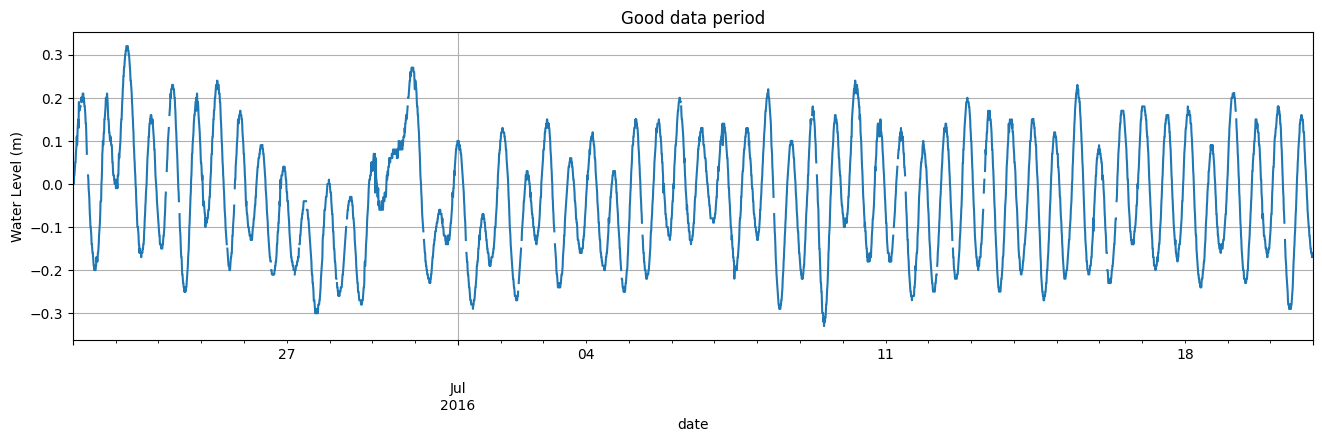

In [20]:
good_data = df_sensors.loc["2016-06-22": "2016-07-20", "obs_3"]
ax = good_data.plot(figsize=(16, 4), grid=True, title='Good data period', ylabel='Water Level (m)')

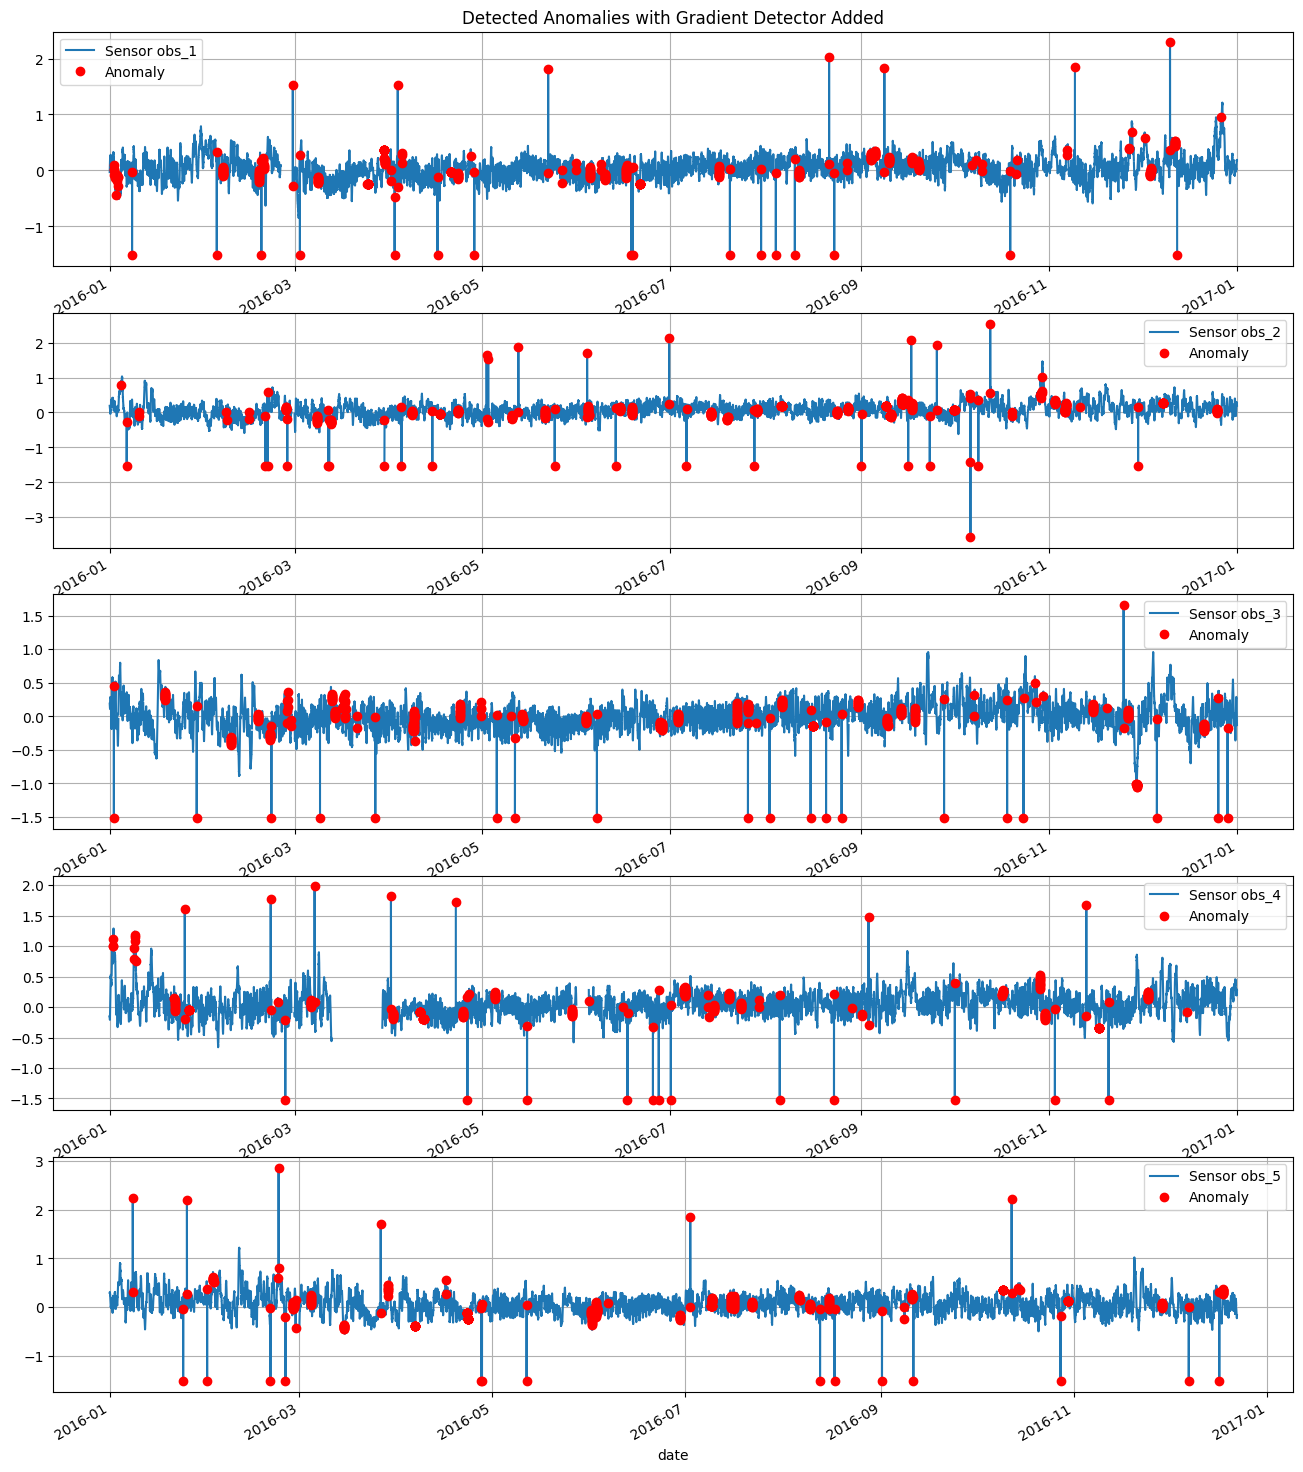

In [21]:
grd_detector = GradientDetector()
grd_detector.fit(good_data)

# Combine detectors
detector = CombinedDetector([
    range_detector, constgrad_detector, grd_detector
])

# Apply detector to entire DataFrame at once
anomalies = detector.detect(df_sensors)
fig, ax = plt.subplots(5, 1, figsize=(16, 20))
ax[0].set_title('Detected Anomalies with Gradient Detector Added')
for axis, col in zip(ax, df_sensors.columns):
    df_sensors[col].plot(ax=axis, grid=True, label=f'Sensor {col}')
    df_sensors[col][anomalies[col]].plot(style="ro", label="Anomaly", ax=axis, grid=True)
    axis.legend()

### Cleaned data

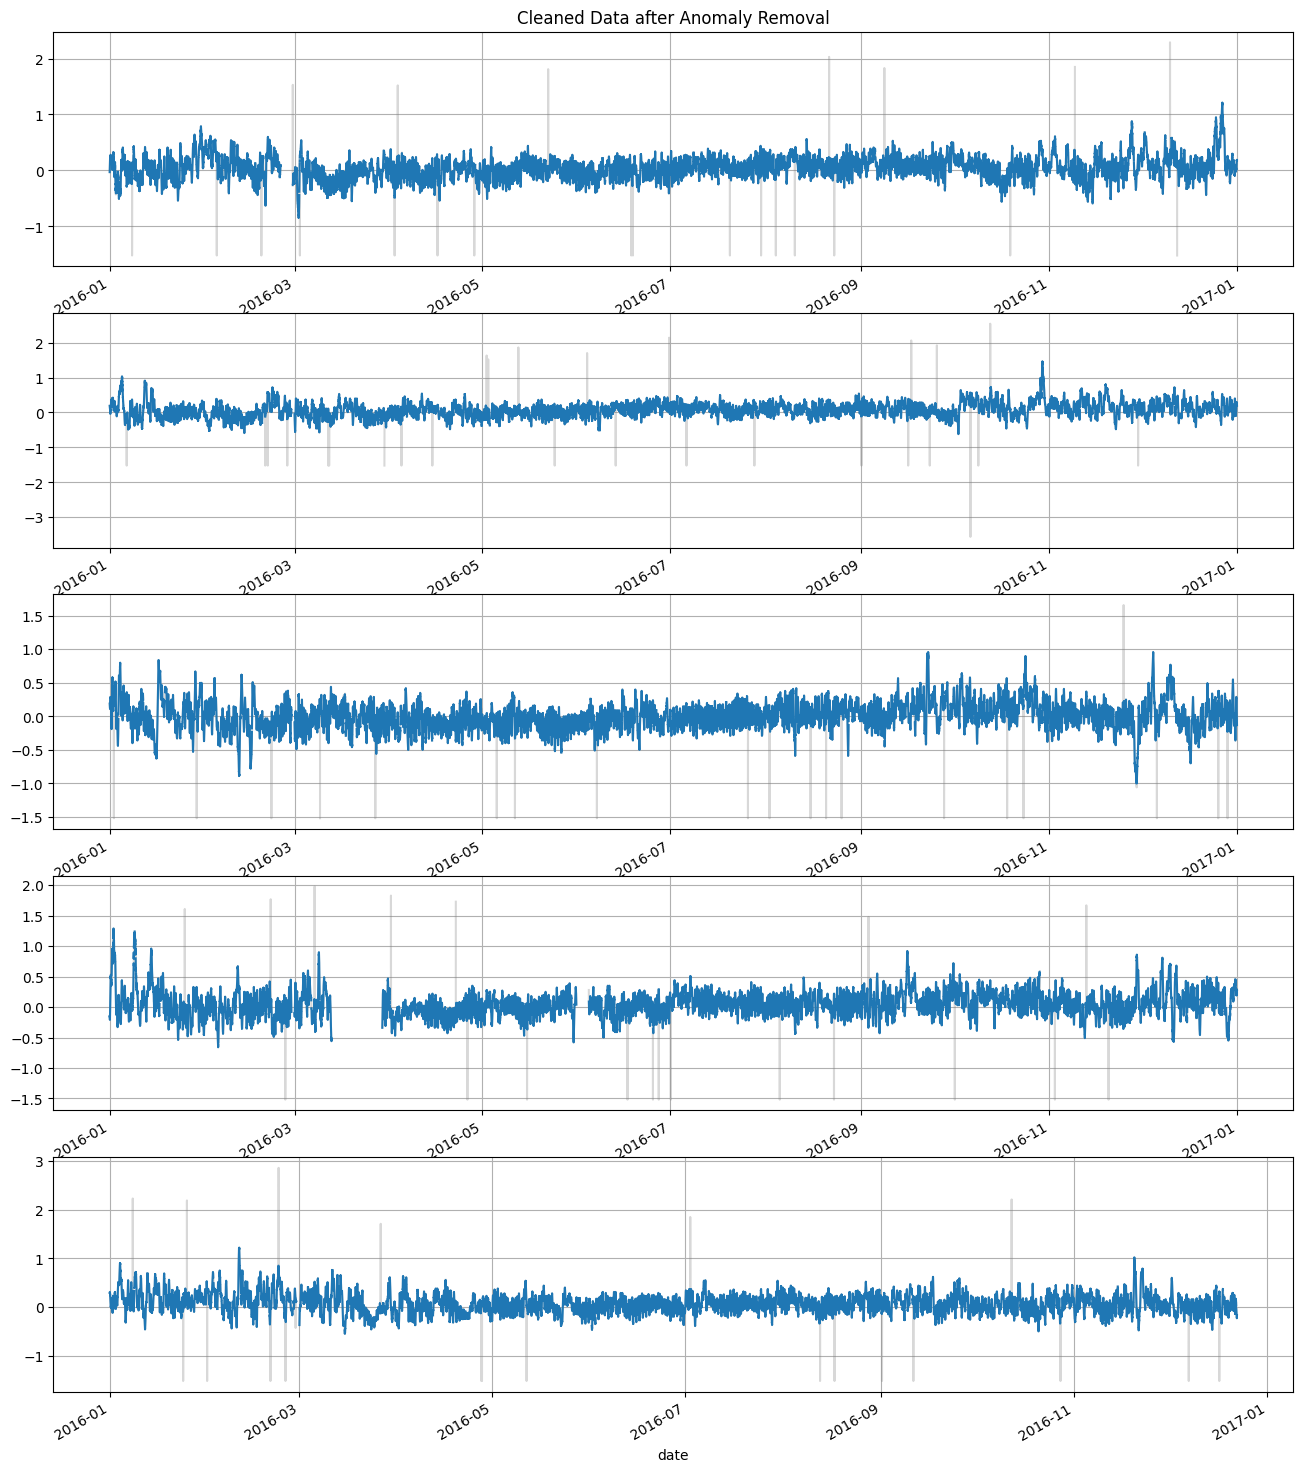

In [22]:
df_sensors_cleaned = df_sensors.mask(anomalies)
fig, ax = plt.subplots(5, 1, figsize=(16, 20))
ax[0].set_title('Cleaned Data after Anomaly Removal')
for axis, col in zip(ax, df_sensors.columns):
    df_sensors[col].plot(ax=axis, grid=True, alpha=0.3, color='gray')
    df_sensors_cleaned[col].plot(ax=axis, grid=True)
